# Weibull Distribution

## 1. Purpose

This notebook analyzes the Weibull distribution in the context of reliability engineering. The objective is to compute reliability metrics such as PDF, CDF, hazard rate, and MTTF, and apply them to engineering problems.

## 2. Mathematical Model

The Weibull probability density function is:

$$
f(x) = \frac{\beta}{\alpha} \left(\frac{x}{\alpha}\right)^{\beta - 1} e^{-(x/\alpha)^\beta}
$$

The cumulative distribution function is:

$$
F(x) = 1 - e^{-(x/\alpha)^\beta}
$$

The mean time to failure (MTTF) is:

$$
\text{MTTF} = \alpha \, \Gamma\left(1 + \frac{1}{\beta}\right)
$$

The Reliability function is:

$$
R(x) = e^{-(x/\alpha)^\beta}
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma
from scipy.stats import weibull_min

In [ ]:
def weibull_pdf(x, beta, alpha):
    return (beta/alpha) * (x/alpha)**(beta - 1) * np.exp(-(x/alpha)**beta)

def weibull_cdf(x, beta, alpha):
    return 1 - np.exp(-(x/alpha)**beta)

def weibull_mttf(beta, alpha):
    return alpha * gamma(1 + 1/beta)

def weibull_hazard(x, beta, alpha):
    return weibull_pdf(x, beta, alpha) / (1 - weibull_cdf(x, beta, alpha))

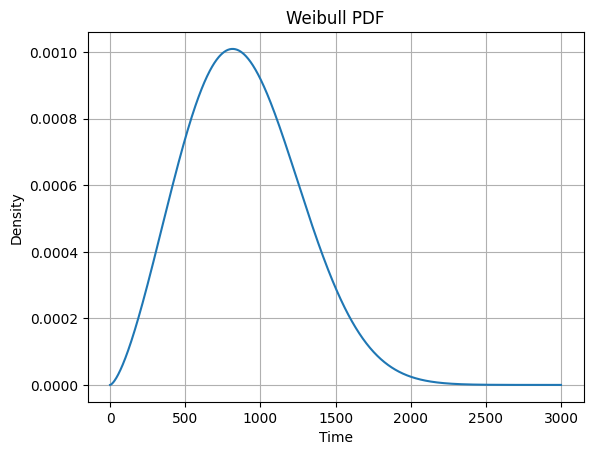

In [3]:
# Visualization

x = np.linspace(0, 3000, 1000)
beta = 2.5
eta = 1000

pdf = weibull_pdf(x, beta, eta)

plt.plot(x, pdf)
plt.title("Weibull PDF")
plt.xlabel("Time")
plt.ylabel("Density")
plt.grid()
plt.show()

# Exercises

## Exercise 3.2
Time to failure of a relay follows a Weibull distribution with $\alpha = 10$ years, $\beta=0.5$. Find the following:

a. Pr(failure after 1 year)
b. Pr(failure after 10 years)
c. MTTF

### Solution

Weibull cdf returns the failure rate until moment $x$. If we sought for failure _after_ that moment, then we need to calculate the complementary probability, i.e.:

$$
P(T > t) = 1 - F(x) = 1 - 1 + e^{-(x/\alpha)^\beta} = e^{-(x/\alpha)^\beta}
$$

In [ ]:
# Inputs
alpha = 10
beta = 0.5
year_a = 1
year_b = 10

# A failure after 1 year
pr_1year = 1 - weibull_cdf(year_a, beta, alpha)

# A failure after 10 years
pr_10years = 1 - weibull_cdf(year_b, beta, alpha)

# MTTF expected
mttf = weibull_mttf(beta, alpha)

print("Probability of failure after 1 year:", pr_1year)
print("Probability of failure after 10 years:", pr_10years)
print("MTTF:", mttf)

Probability of failure after 1 year: 0.7288934141100246
Probability of failure after 10 years: 0.36787944117144233
MTTF: 20.0


## Exercise 3.11

It requires comparing exponential and weibull to set the better fit. The complete solution (which is better is weibull) is available at the other notebook (01_exponential.ipynb)

## Exercise 3.18

One hundred and twenty four devices are placed on an overstress teste with failures at the following times:

|Time (h)| 0.4 | 1 | 2 | 5 | 8 | 12 | 25 |
|--------|-----|---|---|---|---|----|----|
|Total number of failures| 1 | 3 | 5 | 15 | 20 | 30 | 50

a. Plot the data on Weibull probability paper.
b. Estimate the shape parameter.
c. Estimate the scale paremeter.
d. What other distributions may also represent the data?

Cumulative Failures: [  0.62   3.62   8.62  23.62  43.62  73.62 123.62]
Slope: 1.5786440064532836
Intercept: -3.808526151483795
R^2: 0.9829429672510376
----------------------------------------
Estimated Weibull parameters: alpha = 11.16, beta = 1.58
----------------------------------------
   Failure Hour  Cumulative Failures       CDF  Reliability  Log(Time)  \
0           0.4                  1.0  0.005000     0.995000  -0.916291   
1           1.0                  4.0  0.029194     0.970806   0.000000   
2           2.0                  9.0  0.069516     0.930484   0.693147   
3           5.0                 24.0  0.190484     0.809516   1.609438   
4           8.0                 44.0  0.351774     0.648226   2.079442   
5          12.0                 74.0  0.593710     0.406290   2.484907   
6          25.0                124.0  0.996935     0.003065   3.218876   

   Log(1/Rt)  -Log(1/Rt)  Log(Log(1/Rt))  
0   0.005013   -0.005013       -5.295812  
1   0.029628   -0.029628      

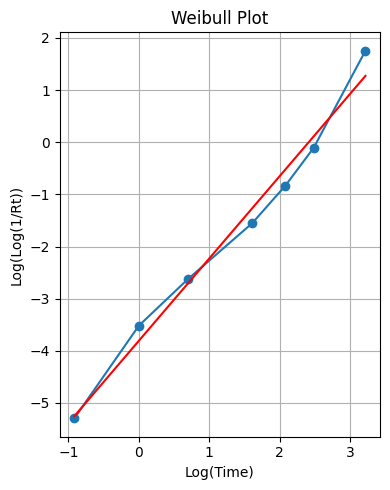

In [45]:
## Solution for Exercise 3.18
# Item a

# Minimum imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Solution - Example 3.11

n = 124
#! The author used a short trick to make the calculation fits the bill to avoid ln(0) = infinity
data = np.array([0.62, 3, 5, 15, 20, 30, 50])
failure_hour = np.array([0.4, 1, 2, 5, 8, 12, 25])
data_cumsum = np.cumsum(data)
print("Cumulative Failures:", data_cumsum)
cdf_data = data_cumsum / n
rt_data = 1 - cdf_data

data_df = pd.DataFrame({
    'Failure Hour': failure_hour,
    'Cumulative Failures': np.round(data_cumsum,0),
    'CDF': cdf_data,
    'Reliability': rt_data
})

log_rt_inverse = np.log(1 / rt_data)
log_log_rt_inverse = np.log(log_rt_inverse)
log_time = np.log(failure_hour)

data_df['Log(Time)'] = log_time
data_df['Log(1/Rt)'] = log_rt_inverse
data_df['-Log(1/Rt)'] = -log_rt_inverse
data_df['Log(Log(1/Rt))'] = log_log_rt_inverse

# Now, need to fit to line these data points to find the slope and intercept.
# Linear regression to estimate parameters of Weibull distribution
from scipy.stats import linregress

x = data_df['Log(Time)']
y = data_df['Log(Log(1/Rt))']
result = linregress(x, y)

print(f"Slope: {result.slope}")
print(f"Intercept: {result.intercept}")
print(f"R^2: {result.rvalue**2}")

# Calculating approximate \alpha and \beta parameters of Weibull distribution
beta_ex_3_18 = result.slope
alpha_ex_3_18 = np.exp(-result.intercept / beta_ex_3_18)
print(f"----------------------------------------")
print(f"Estimated Weibull parameters: alpha = {alpha_ex_3_18:.2f}, beta = {beta_ex_3_18:.2f}")
print(f"----------------------------------------")

print(data_df)

plt.figure(figsize=(4, 5))
plt.plot(log_time, log_log_rt_inverse, marker='o')
plt.plot(log_time, result.intercept + result.slope * log_time, color='red', label='Fitted Line')
plt.title('Log(Log(1/Rt)) vs Log(Time)')
plt.xlabel('Log(Time)')
plt.ylabel('Log(Log(1/Rt))')
plt.title('Weibull Plot')
plt.grid()

plt.tight_layout()
plt.show()

Slope: -0.2269624125497092
Intercept: 0.6685305639370955
R^2: 0.8812888880100364
----------------------------------------
Estimated Exponential parameters: lambda = -0.2270
----------------------------------------


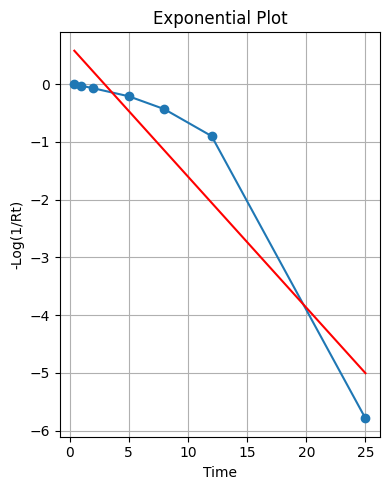

In [44]:
# Item d

# Trying to fit exponential

x = data_df['Failure Hour']
y = data_df['-Log(1/Rt)']
result_exp = linregress(x, y)
print(f"Slope: {result_exp.slope}")
print(f"Intercept: {result_exp.intercept}")
print(f"R^2: {result_exp.rvalue**2}")

print(f"----------------------------------------")
print(f"Estimated Exponential parameters: lambda = {result_exp.slope:.4f}")
print(f"----------------------------------------")

plt.figure(figsize=(4, 5))
plt.plot(data_df['Failure Hour'], data_df['-Log(1/Rt)'], marker='o')
plt.plot(data_df['Failure Hour'], result_exp.intercept + result_exp.slope * data_df['Failure Hour'], color='red', label='Fitted Line')
plt.title('Log(1/Rt) vs Time')
plt.xlabel('Time')
plt.ylabel('-Log(1/Rt)')
plt.title('Exponential Plot')
plt.grid()
plt.tight_layout()
plt.show()

CDF values: 0    0.005000
1    0.029194
2    0.069516
3    0.190484
4    0.351774
5    0.593710
6    0.996935
Name: CDF, dtype: float64
Log (Time) values: 0   -0.916291
1    0.000000
2    0.693147
3    1.609438
4    2.079442
5    2.484907
6    3.218876
Name: Log(Time), dtype: float64
Z-scores for the given CDF values: [-2.5758293  -1.89278027 -1.47940443 -0.87611459 -0.38053491  0.23709815
  2.74079721]
Slope: 1.103672450774102
Intercept: -2.049558993618039
R^2: 0.847665402648729
----------------------------------------
Estimated Lognormal parameters: mean = 1.86, stdev = 0.91
----------------------------------------


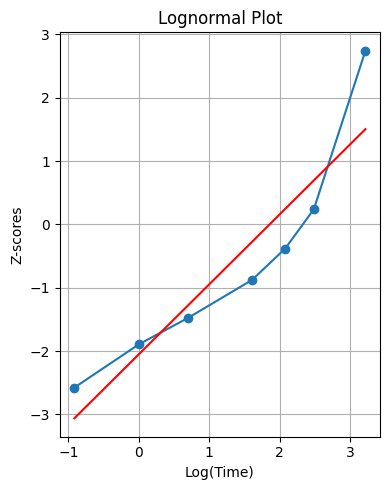

In [ ]:
# Item d
# Import inverse cdf of standard normal distribution
from scipy.stats import norm

# Fit to lognormal distribution
# phi^(-1)(F(t) = 1/stdev * t_i - mean/stdev)
cdf = data_df['CDF']
z_scores = norm.ppf(cdf)
print("CDF values:", data_df['CDF'])
print("Log (Time) values:", data_df['Log(Time)'])
print("Z-scores for the given CDF values:", z_scores)
x = data_df['Log(Time)']
y = z_scores
result_lognormal = linregress(x, y)
print(f"Slope: {result_lognormal.slope}")
print(f"Intercept: {result_lognormal.intercept}")
print(f"R^2: {result_lognormal.rvalue**2}")

# Recalling that
# stdev = 1 / slope
# mean = -intercept / slope
print(f"----------------------------------------")
print(f"Estimated Lognormal parameters: mean = {-result_lognormal.intercept / result_lognormal.slope:.2f}, stdev = {1 / result_lognormal.slope:.2f}")
print(f"----------------------------------------")

plt.figure(figsize=(4, 5))
plt.plot(data_df['Log(Time)'], z_scores, marker='o')
plt.plot(data_df['Log(Time)'], result_lognormal.intercept + result_lognormal.slope * data_df['Log(Time)'], color='red', label='Fitted Line')
plt.title('Z-scores vs Log(Time)')
plt.xlabel('Log(Time)')
plt.ylabel('Z-scores')
plt.title('Lognormal Plot')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Notes about 3.18

The proposed solution in this notebook for items a, b and c match with the ones found in the solution manual. However, item d has a significant divergent regarding lognormal fit.
According to the author:
$$
\mu_t = 8.38 \\
\sigma_t = 1.53
$$

Just to reverse and cross check:
$$
F(t) = \phi \left[  \frac{ln(t_i) - \mu_t}{\sigma_t} \right]
$$

If we replace $ln(t_i)$ by the very first point, 0.4 hours, we got we are expected to find $\phi(-2.57)$ which is close to 0.05 that it is our first cdf point calculated. However,
$$
\left[ \frac{ln(0.4)-8.38}{1.53}\right] = \left[ \frac{-0.92-8.38}{1.53}\right] = -6.07
$$

Thus, author made some miscalculation somewhere to arrive at these points. The linear fit presented in the solution arrives at $-3.05$ which is not perfectly the first point, but it is not off by several z-scale units. Thus, for this exercise we disregard the author conclusion for lognormal.

Nevertheless, as lognormal fit is somewhat acceptable, we did not pursue normal fit as it would be a worse candidate.
